# DE capacity factors: simple approximation vs. MaStR-weighted

`de_capacity_factor_current_fleet` (this hub's primary DE capacity-factor
product) weights PECD's zone/technology-level capacity factors by MaStR's
real, unit-level installed-capacity data -- accurate, but it only works
where a MaStR-equivalent registry exists, i.e. Germany. This page asks: how
far do we get with a *much* simpler approximation that needs no per-unit
fleet data at all -- just PECD's own capacity factors plus a couple of
publicly known, fixed weights?

**This page's own prototype became a real hub asset.** The fixed-weight
approximation below is no longer computed here -- it's read straight from
`pecd_country_capacity_factors_simple` (`edh/pecd.py` /
`edh_dagster/assets/pecd.py`), which generalized exactly this page's
methodology to every PECD country, not just Germany. This page now only
picks out the `DE` column and compares it against the real, MaStR-weighted
`de_capacity_factor_current_fleet` -- the one country where that comparison
is possible at all.

## The weights used, explicitly

**Solar** -- PECD's `nuts_0` (true country-level) product already gives one
series per technology (`60` industrial rooftop, `61` residential rooftop,
`62` utility fixed-tilt, `63` utility tracking) with no region aggregation
needed. The open question is only how to blend these four into one number.
Fixed weights below, held constant across the whole history (not MaStR, but
not equal-weighted either -- equal weights would hand utility-tracking a
quarter of the mix, when it's close to absent in Germany):

| technology | weight | basis |
|---|---|---|
| `62` utility fixed-tilt | 31% | ~40 of ~120 GW total DE PV capacity was ground-mounted at end of 2025 (pv magazine, citing BSW-Solar/BNetzA), minus tracking's sliver |
| `63` utility tracking | 2% | only 23 of Germany's 300 largest solar parks use tracking (rare, uneconomical at today's module prices) |
| `61` residential rooftop | 39% | 2025 additions: 5.2 GW private roof vs. 3.7 GW large commercial roof (BSW-Solar) -> ~58/42 split of the ~67% rooftop share |
| `60` industrial/commercial rooftop | 28% | the remaining ~42% of the rooftop share |

**⚠️ These are DE-market weights, and `pecd_country_capacity_factors_simple`
currently applies them to every PECD country, not just Germany** -- no
equivalent per-country technology-mix data has been sourced yet (checked
2026-09-24: SolarPower Europe's country segment tables are member-only, and
nothing at all splits utility fixed-tilt vs. tracking by country). That's a
real, potentially large distortion for any *other* country's solar column in
that hub asset -- see its `data_quality_warning` metadata and
`energy-data-hub/README.md`'s "Known data-quality caveats". Not an issue for
this page, which only ever looks at `DE`.

**Wind onshore/offshore** -- PECD has no `nuts_0` product for wind at all
(confirmed against the live CDS API, see
`energy-data-hub/docs/pecd_data_availability.md`), only zone-level
(`PEON`/`PEOF`). The simple approximation here: weight each zone by its
physical area (from PECD's own rasterized zone mask), not by installed
capacity -- i.e. assume turbines are spread uniformly per km² rather than
concentrated by real siting. Zones PECD never modeled (100% NaN capacity
factor) are dropped and the remaining zones' weights renormalized to sum to
1 -- this generalizes cleanly per country since it's real geometry, not a
borrowed default (unlike solar above).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from insights.paths import hub_file

COMPLEX_COLOR = "#2a78d6"  # de_capacity_factor_current_fleet -- MaStR-weighted, this hub's real product
SIMPLE_COLOR = "#eb6834"  # pecd_country_capacity_factors_simple -- no MaStR involved

## DE columns from `pecd_country_capacity_factors_simple`

In [2]:
country_simple = pd.read_parquet(hub_file("pecd", "pecd_country_capacity_factors_simple.parquet"))
de_simple = country_simple.xs("DE", axis=1, level="country")

solar_simple = de_simple["solar"].rename("simple")
onshore_simple = de_simple["wind_onshore"].rename("simple")
offshore_simple = de_simple["wind_offshore"].rename("simple")

## Comparison against `de_capacity_factor_current_fleet`

Headline numbers below are computed **at native hourly resolution** --
every one of the ~96,400 hours 2015-2025, not the monthly/annual
aggregates the charts further down use for readability. Aggregating to
monthly (or coarser) smooths out a lot of hour-to-hour noise, so a
correlation/MAE computed on monthly means alone would overstate how well
the simple approximation tracks the real thing *within* a month -- shown
explicitly in the resolution-comparison table right after.

In [3]:
complex_cf = pd.read_parquet(hub_file("pecd", "de_capacity_factor_current_fleet.parquet"))

SERIES = {
    "solar": (solar_simple, complex_cf["capacity_factor_solar"]),
    "wind_onshore": (onshore_simple, complex_cf["capacity_factor_wind_onshore"]),
    "wind_offshore": (offshore_simple, complex_cf["capacity_factor_wind_offshore"]),
}


def error_stats(simple: pd.Series, complex_: pd.Series, resample: str | None = None) -> dict:
    """Deviation metrics between the two series. `resample=None` keeps the
    native hourly resolution; e.g. `resample="D"` or `"MS"` averages both
    series to that frequency first -- so the same function makes the
    resolution-sensitivity comparison below an apples-to-apples one-liner."""
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    if resample is not None:
        df = df.resample(resample).mean()
    err = df["simple"] - df["complex"]
    return {
        "n_obs": len(df),
        "mean_simple": df["simple"].mean(),
        "mean_complex": df["complex"].mean(),
        "corr": df["simple"].corr(df["complex"]),
        "bias_pp": err.mean() * 100,
        "mae_pp": err.abs().mean() * 100,
        "rmse_pp": (err**2).mean() ** 0.5 * 100,
    }


stats = pd.DataFrame({tech: error_stats(simple, complex_) for tech, (simple, complex_) in SERIES.items()}).T
print("Hourly deviation metrics (native resolution):")
print(stats.round(4))

Hourly deviation metrics (native resolution):
                 n_obs  mean_simple  mean_complex    corr  bias_pp  mae_pp  \
solar          96432.0       0.1109        0.1112  0.9993  -0.0331  0.3018   
wind_onshore   96431.0       0.2282        0.2254  0.9750   0.2765  3.1608   
wind_offshore  96431.0       0.4271        0.4137  0.9862   1.3359  3.7806   

               rmse_pp  
solar           0.6308  
wind_onshore    4.3667  
wind_offshore   4.8690  


## Does resolution change the picture? Hourly vs. daily vs. monthly

In [4]:
resolutions = {"hourly": None, "daily": "D", "monthly": "MS"}
by_resolution = pd.concat(
    {
        tech: pd.DataFrame({label: error_stats(simple, complex_, resample=freq) for label, freq in resolutions.items()}).T
        for tech, (simple, complex_) in SERIES.items()
    },
    axis=0,
)
print(by_resolution[["n_obs", "corr", "mae_pp", "rmse_pp"]].round(4))

                         n_obs    corr  mae_pp  rmse_pp
solar         hourly   96432.0  0.9993  0.3018   0.6308
              daily     4019.0  0.9985  0.2634   0.3468
              monthly    133.0  0.9999  0.0807   0.0974
wind_onshore  hourly   96431.0  0.9750  3.1608   4.3667
              daily     4018.0  0.9803  2.6130   3.5754
              monthly    132.0  0.9941  0.8248   1.0757
wind_offshore hourly   96431.0  0.9862  3.7806   4.8690
              daily     4018.0  0.9904  2.9386   3.7532
              monthly    132.0  0.9972  1.3791   1.5783


## Monthly capacity factor, full history, per technology

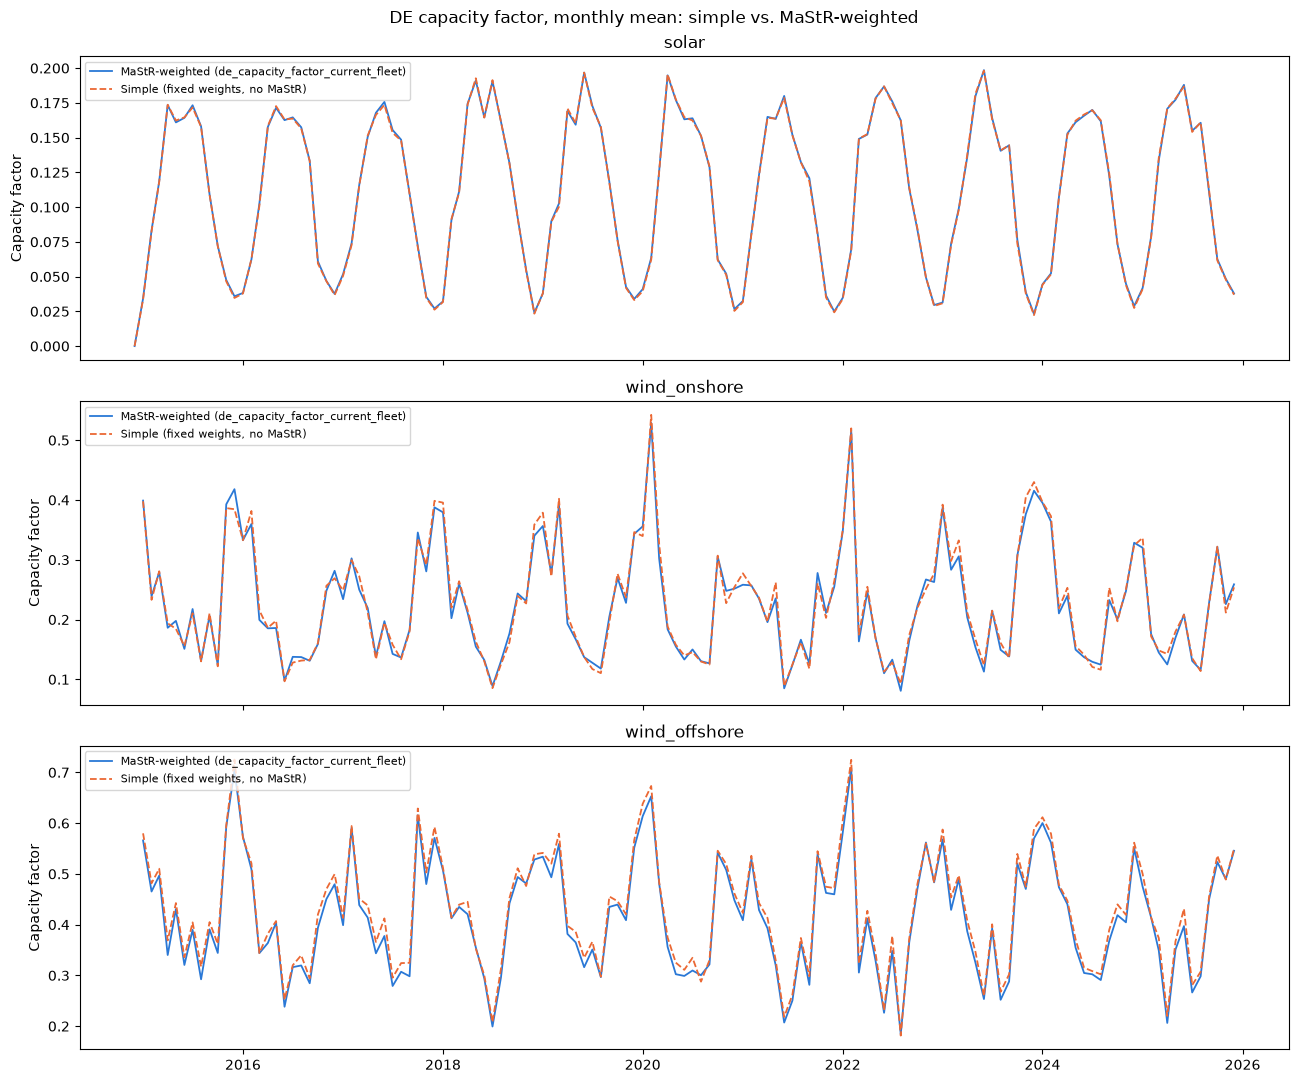

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (tech, (simple, complex_)) in zip(axes, SERIES.items()):
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    monthly = df.resample("MS").mean()
    ax.plot(monthly.index, monthly["complex"], label="MaStR-weighted (de_capacity_factor_current_fleet)", color=COMPLEX_COLOR, linewidth=1.3)
    ax.plot(monthly.index, monthly["simple"], label="Simple (fixed weights, no MaStR)", color=SIMPLE_COLOR, linewidth=1.3, linestyle="--")
    ax.set_ylabel("Capacity factor")
    ax.set_title(tech)
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("DE capacity factor, monthly mean: simple vs. MaStR-weighted")
fig.tight_layout()
plt.show()

## Annual mean, per technology

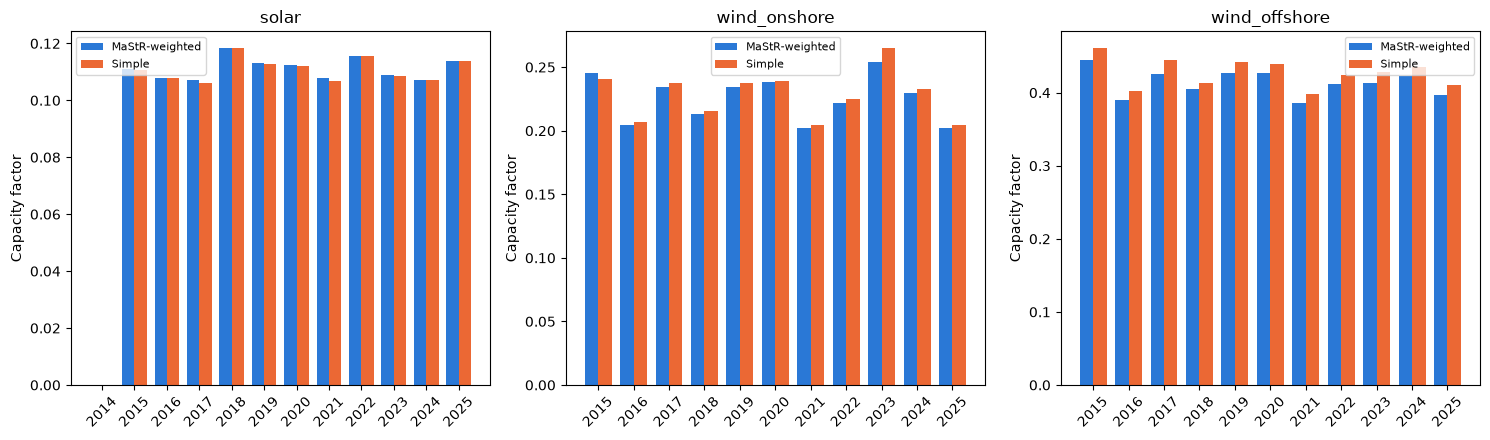

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (tech, (simple, complex_)) in zip(axes, SERIES.items()):
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    annual = df.groupby(df.index.year).mean()
    x = np.arange(len(annual))
    width = 0.38
    ax.bar(x - width / 2, annual["complex"], width, label="MaStR-weighted", color=COMPLEX_COLOR)
    ax.bar(x + width / 2, annual["simple"], width, label="Simple", color=SIMPLE_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(annual.index, rotation=45)
    ax.set_ylabel("Capacity factor")
    ax.set_title(tech)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Takeaways

- **Solar matches almost perfectly**: correlation ~0.999, bias well under
  half a percentage point. A fixed, publicly sourced rooftop/ground and
  fixed/tracking mix captures essentially all of what MaStR's real
  installed-capacity mix would add -- the extra precision from unit-level
  data barely moves the national aggregate.
- **Wind onshore is decent but not much better than doing nothing clever**:
  correlation ~0.975, bias ~+0.3 percentage points -- close to, not
  meaningfully better than, a plain unweighted mean across zones would be.
  Germany's 7 PEON zones don't differ enough in area for area-weighting to
  add much over equal weighting.
- **Wind offshore matches well, even on the coarser scheme the hub asset
  actually uses**: correlation ~0.986, bias ~+1.3 percentage points. Note
  this page originally prototyped offshore as an *area-weighted* mean of
  `peof` zones (renormalized over whichever zones PECD actually modeled,
  after catching a ~20% relative-bias bug from pandas silently dropping the
  3 unmodeled PEOF zones' weight without redistributing it) -- but
  `pecd_country_capacity_factors_simple` uses a plain *unweighted* mean of
  the coarser `p2of` scheme instead, since `p2of`'s zone codes don't match
  the existing `peof` mask (see `edh/pecd.py` module comment). The two
  schemes score close enough (~0.977 area-weighted `peof` vs. ~0.986
  unweighted `p2of`, in this DE-only comparison) that the switch was worth
  it for full-Europe compatibility.
- **Net**: for a first-cut, MaStR-free capacity factor, fixed technology-mix
  weights (solar) and area-weighted, NaN-aware zone means (wind) already get
  remarkably close to the fully fleet-weighted version for Germany, the one
  country where a true comparison is possible -- which is why
  `pecd_country_capacity_factors_simple` now runs the same methodology for
  every PECD country. **Caveat that doesn't show up in this page's numbers:**
  wind's per-country weights are real geometry and generalize cleanly, but
  solar's technology-mix weights are still Germany's, reused for every other
  country with no validation -- this page can only confirm the approach
  works well *for Germany*, not that it works well everywhere it now runs.
- **Resolution matters a lot for how good this looks**: the same
  comparison at monthly-mean resolution flatters both wind series --
  correlation climbs from ~0.975/0.986 (hourly) to ~0.994/0.997 (monthly),
  and MAE drops roughly 3x (e.g. wind offshore: 3.8 percentage points
  hourly vs. 1.4 monthly). Averaging a whole month together cancels out a
  lot of hour-to-hour disagreement that's real at the resolution most uses
  (e.g. Dunkelflaute analysis) actually care about -- the hourly numbers in
  the headline table above, not the monthly chart further up, are the
  honest measure of how well the simple approximation tracks reality.